# Naive Bayes — Análisis de sentimiento de tweets

En este notebook construimos un clasificador **Naive Bayes** para predecir el sentimiento (**positivo** o **negativo**) de tweets.

## 1. Importar bibliotecas

In [66]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

## 2. Cargar y explorar el dataset

Usamos **Sentiment140**: 1.6M de tweets en inglés etiquetados por sentimiento.

In [67]:
%pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("ferno2/training1600000processednoemoticoncsv")
csv_path = f"{path}/training.1600000.processed.noemoticon.csv"
print("Dataset en:", csv_path)

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Dataset en: /Users/ignacioaracena/.cache/kagglehub/datasets/ferno2/training1600000processednoemoticoncsv/versions/1/training.1600000.processed.noemoticon.csv


Leemos el CSV con `pandas`. Como el archivo no trae encabezado, nombramos las 6 columnas.

In [68]:
df = pd.read_csv(
    csv_path,
    encoding="latin-1",
    header=None,
    names=["target", "id", "date", "flag", "user", "text"],
)
print("Forma del dataset:", df.shape)

Forma del dataset: (1600000, 6)


### Primer vistazo

`head()` muestra las primeras filas para ver la estructura real de los datos.

In [69]:
df.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


`info()` resume columnas, tipos de dato, nulos y uso de memoria.

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


### ¿Están balanceadas las clases?

La columna `target` es la etiqueta de sentimiento de cada tweet. 

Viene con la codificación del dataset Sentiment140: **0 = negativo** y **4 = positivo** 

Más adelante la traducimos a `negativo` / `positivo` para que se lea claro. Primero contamos cuántos hay de cada una (en número y en %).

In [71]:
conteo = df["target"].map({0: "negativo", 4: "positivo"}).value_counts()
print(conteo)
print()
print((conteo / len(df) * 100).round(1).astype(str) + " %")

target
negativo    800000
positivo    800000
Name: count, dtype: int64

target
negativo    50.0 %
positivo    50.0 %
Name: count, dtype: object


Y lo vemos en un gráfico de barras, que hace evidente el balance.

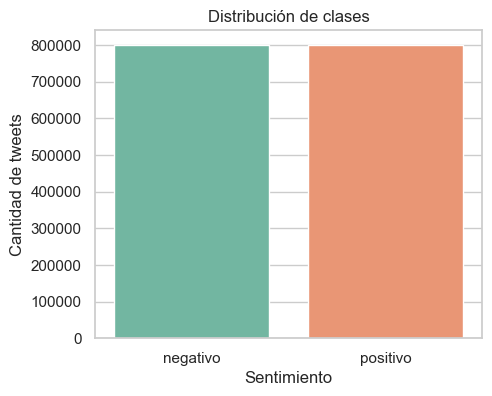

In [72]:
plt.figure(figsize=(5, 4))
sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index, palette="Set2", legend=False)
plt.title("Distribución de clases")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de tweets")
plt.show()

### Longitud de los tweets

Medimos el largo de cada tweet de dos formas: en **caracteres** (`str.len()`) y en **palabras** (`str.split()`).

         caracteres      palabras
count  1.600000e+06  1.600000e+06
mean   7.409011e+01  1.317615e+01
std    3.644114e+01  6.957978e+00
min    6.000000e+00  1.000000e+00
25%    4.400000e+01  7.000000e+00
50%    6.900000e+01  1.200000e+01
75%    1.040000e+02  1.900000e+01
max    3.740000e+02  6.400000e+01


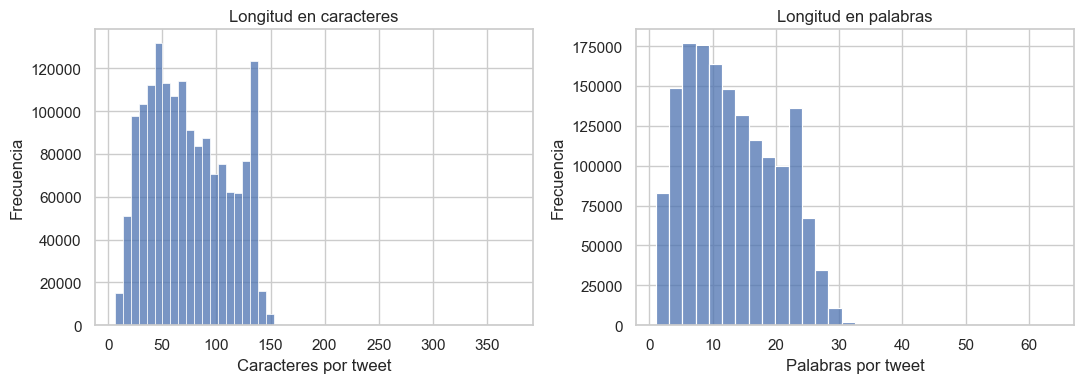

In [73]:
largos = pd.DataFrame({
    "caracteres": df["text"].str.len(),
    "palabras": df["text"].str.split().str.len(),
})
print(largos.describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(largos["caracteres"], bins=50, ax=axes[0])
axes[0].set_title("Longitud en caracteres")
axes[0].set_xlabel("Caracteres por tweet")
axes[0].set_ylabel("Frecuencia")
sns.histplot(largos["palabras"], bins=30, ax=axes[1])
axes[1].set_title("Longitud en palabras")
axes[1].set_xlabel("Palabras por tweet")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

**Cómo interpretarlo:** `mean` es el largo promedio y `std` cuánto varía; la **mediana (50%)** es el largo típico y los cuartiles 25%/75% marcan el rango donde cae la mayoría. Lo vemos en **caracteres** y en **palabras**: son tweets cortos (≤ ~140 caracteres, ~pocas palabras), o sea poco texto por documento. Por eso la matriz Bag-of-Words queda **dispersa** y un modelo simple como Naive Bayes funciona bien. También ayuda a detectar outliers o tweets que quedan casi vacíos tras la limpieza.

### Longitud por clase

¿Los tweets negativos son más largos o más cortos que los positivos? Un boxplot lo muestra rápido.

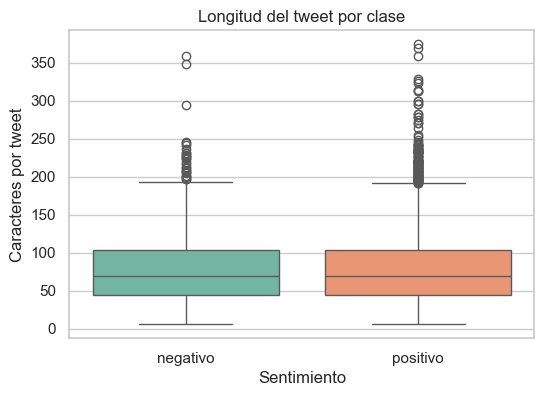

In [74]:
df_eda = df[["target", "text"]].copy()
df_eda["sentimiento"] = df_eda["target"].map({0: "negativo", 4: "positivo"})
df_eda["largo"] = df_eda["text"].str.len()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_eda, x="sentimiento", y="largo", hue="sentimiento", palette="Set2", legend=False)
plt.title("Longitud del tweet por clase")
plt.xlabel("Sentimiento")
plt.ylabel("Caracteres por tweet")
plt.show()

### Qué sabemos del dataset

- **Tipo:** texto libre → datos **no estructurados**.
- **Volumen:** ~1.6M de tweets.
- **Variables:** usamos `text` (entrada) y `target` (salida); `id`, `date`, `flag` y `user` no aportan al modelo.
- **Idioma:** inglés → al vectorizar usamos stopwords en inglés.
- **Clases:** balanceadas (~50% / 50%).

## 3. Limpieza y preprocesamiento

El texto de redes sociales viene sucio (menciones, links, símbolos). Lo normalizamos antes de modelar.

### Función de limpieza

Pasa todo a minúsculas y elimina menciones, URLs y cualquier carácter que no sea una letra.

In [75]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

### Aplicamos la limpieza

Nos quedamos con `target` y `text`, traducimos las etiquetas a `negativo` / `positivo` y limpiamos cada tweet.

In [76]:
df = df[["target", "text"]].copy()
df["target"] = df["target"].map({0: "negativo", 4: "positivo"})
df["text"] = df["text"].apply(clean_text)
df.head()

,target,text
0,negativo,awww thats a bummer you shoulda got david carr...
1,negativo,is upset that he cant update his facebook by t...
2,negativo,i dived many times for the ball managed to sav...
3,negativo,my whole body feels itchy and like its on fire
4,negativo,no its not behaving at all im mad why am i her...


### Muestra de trabajo

In [77]:
df_sample = df.sample(n=50000, random_state=42)
print("Muestra:", df_sample.shape)
df_sample["target"].value_counts()

Muestra: (50000, 2)


target
positivo    25014
negativo    24986
Name: count, dtype: int64

### Nube de palabras por sentimiento

Las palabras más frecuentes de cada clase: cuanto más grande, más aparece. Una forma intuitiva de ver de qué hablan los tweets positivos vs. negativos.

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


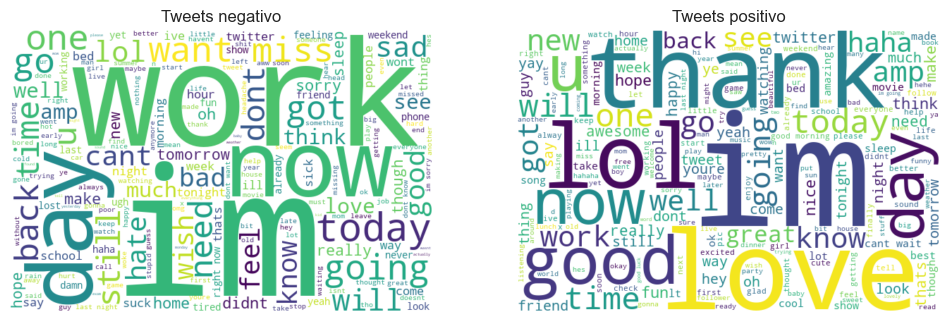

In [78]:
%pip install -q wordcloud
from wordcloud import WordCloud, STOPWORDS

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, clase in zip(axes, ["negativo", "positivo"]):
    texto = " ".join(df_sample.loc[df_sample["target"] == clase, "text"])
    nube = WordCloud(width=600, height=400, background_color="white",
                     stopwords=STOPWORDS).generate(texto)
    ax.imshow(nube, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Tweets {clase}")
plt.show()

### De texto a números: Bag-of-Words

Los modelos no entienden texto, necesitan números. **Bag-of-Words** representa cada tweet por cuántas veces aparece cada palabra del vocabulario, ignorando el orden: `CountVectorizer` arma esa matriz (una fila por tweet, una columna por palabra). Con `stop_words='english'` descartamos las **stopwords**, palabras muy comunes y poco informativas (*the*, *is*, *and*…).

Primero, un ejemplo chico para verlo:

In [79]:
ejemplo = ["I love this movie", "I hate this movie", "what a great film"]
demo_vec = CountVectorizer()
demo_X = demo_vec.fit_transform(ejemplo)

pd.DataFrame(
    demo_X.toarray(),
    columns=demo_vec.get_feature_names_out(),
    index=ejemplo,
)

,film,great,hate,love,movie,this,what
I love this movie,0,0,0,1,1,1,0
I hate this movie,0,0,1,0,1,1,0
what a great film,1,1,0,0,0,0,1


### Vectorizamos la muestra completa

In [80]:
texts = df_sample["text"].tolist()
labels = df_sample["target"].tolist()

vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)

print("Matriz documento-término:", X.shape)
print("Vocabulario:", len(vectorizer.get_feature_names_out()), "palabras")

Matriz documento-término: (50000, 40926)
Vocabulario: 40926 palabras


## 4. Entrenamiento del modelo

**Naive Bayes** es un clasificador probabilístico basado en el teorema de Bayes que asume que las palabras son independientes entre sí; su variante `MultinomialNB` está pensada para conteos de palabras. Hacemos un **train/test split**: entrenamos con el 75% de los datos y evaluamos con el 25% restante, que el modelo nunca vio, para medir si generaliza.

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.25, random_state=42, stratify=labels
)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.3f}")

Accuracy en test: 0.742


### Efecto del suavizado (alpha)

Naive Bayes usa **suavizado de Laplace** (`alpha`) para no asignar probabilidad cero a palabras nuevas. Probamos varios valores y vemos cómo cambia el accuracy.

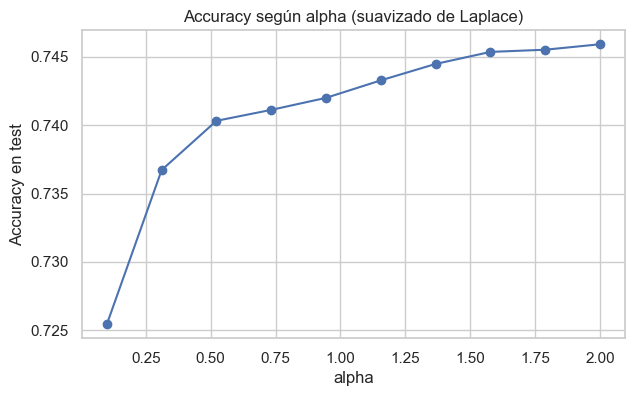

In [82]:
alphas = np.linspace(0.1, 2.0, 10)
accs = []
for a in alphas:
    m = MultinomialNB(alpha=a)
    m.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(7, 4))
plt.plot(alphas, accs, marker="o")
plt.title("Accuracy según alpha (suavizado de Laplace)")
plt.xlabel("alpha")
plt.ylabel("Accuracy en test")
plt.grid(True)
plt.show()

## 5. Análisis de resultados

### Métricas por clase

`classification_report` da precision, recall y f1 por clase.

In [83]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negativo       0.73      0.76      0.75      6246
    positivo       0.75      0.73      0.74      6254

    accuracy                           0.74     12500
   macro avg       0.74      0.74      0.74     12500
weighted avg       0.74      0.74      0.74     12500



La matriz de confusión muestra los aciertos y dónde se confunde el modelo.

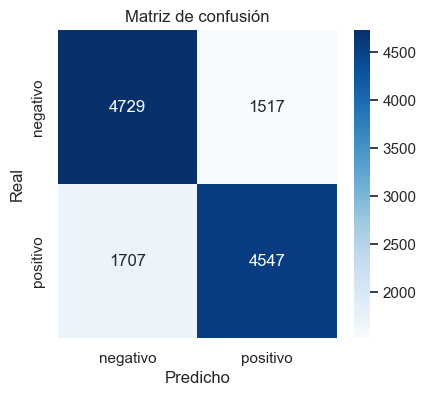

In [84]:
cm = confusion_matrix(y_test, y_pred, labels=["negativo", "positivo"])

plt.figure(figsize=(4.5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["negativo", "positivo"],
    yticklabels=["negativo", "positivo"],
)
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

### Palabras más frecuentes por clase

Las 15 palabras con mayor probabilidad dentro de cada sentimiento, según el modelo.

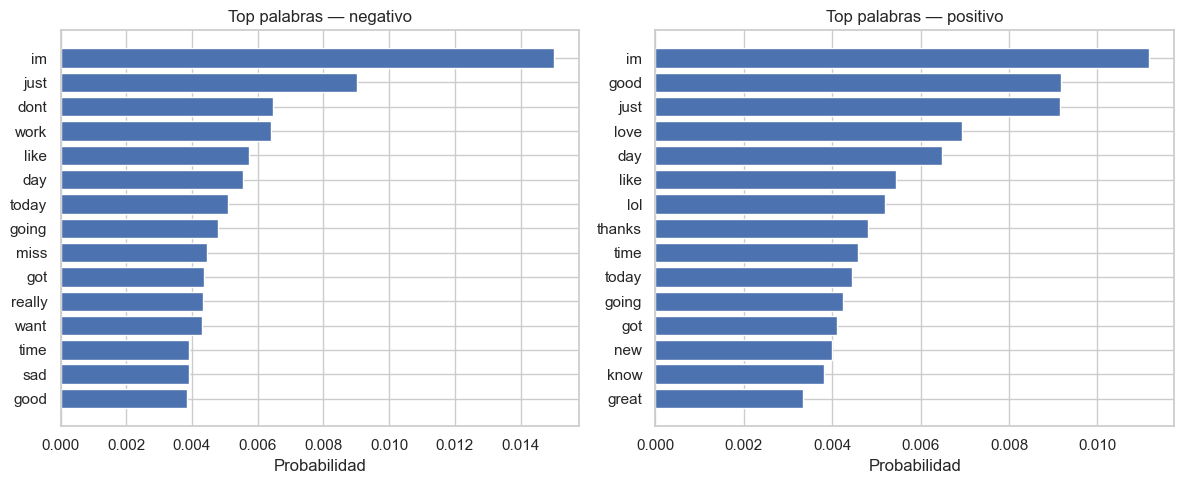

In [85]:
feature_names = np.array(vectorizer.get_feature_names_out())

fig, axes = plt.subplots(1, len(model.classes_), figsize=(12, 5))
for ax, i in zip(axes, range(len(model.classes_))):
    clase = model.classes_[i]
    top = np.argsort(model.feature_log_prob_[i])[-15:]
    ax.barh(feature_names[top], np.exp(model.feature_log_prob_[i][top]), color="#4C72B0")
    ax.set_title(f"Top palabras — {clase}")
    ax.set_xlabel("Probabilidad")
plt.tight_layout()
plt.show()

### Palabras más decisivas

No alcanza con que una palabra sea frecuente: importa cuánto **inclina** la decisión hacia una clase. Acá vemos la diferencia de log-probabilidad entre positivo y negativo: a la derecha las que empujan a *positivo*, a la izquierda a *negativo*.

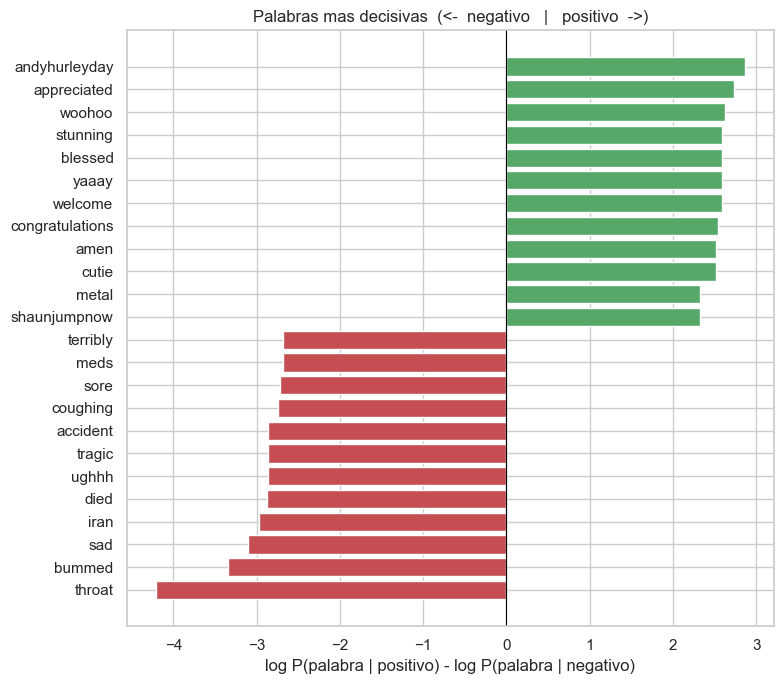

In [86]:
pos_i = list(model.classes_).index("positivo")
neg_i = list(model.classes_).index("negativo")

diff = model.feature_log_prob_[pos_i] - model.feature_log_prob_[neg_i]
orden = np.argsort(diff)
idx = np.concatenate([orden[:12], orden[-12:]])
valores = diff[idx]
colores = ["#C44E52" if v < 0 else "#55A868" for v in valores]

plt.figure(figsize=(8, 7))
plt.barh(feature_names[idx], valores, color=colores)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Palabras mas decisivas  (<-  negativo   |   positivo  ->)")
plt.xlabel("log P(palabra | positivo) - log P(palabra | negativo)")
plt.tight_layout()
plt.show()

### Probar con tweets nuevos

Limpiamos y vectorizamos tweets escritos a mano con el **mismo** vectorizer y predecimos su sentimiento.

In [87]:
nuevos_tweets = [
    "I love this airline, the crew was amazing!",
    "Worst flight ever, my luggage was lost again.",
    "The movie was boring and way too long.",
    "What a beautiful sunny day, I feel great!",
]

nuevos_limpios = [clean_text(t) for t in nuevos_tweets]
nuevos_vec = vectorizer.transform(nuevos_limpios)
predicciones = model.predict(nuevos_vec)

for tweet, pred in zip(nuevos_tweets, predicciones):
    print(f"[{pred}] {tweet}")

[positivo] I love this airline, the crew was amazing!
[negativo] Worst flight ever, my luggage was lost again.
[negativo] The movie was boring and way too long.
[positivo] What a beautiful sunny day, I feel great!
